In [1]:
# ============================================================
# 05 - Análise de Prêmio de Mercado
# Fonte: SUSEP AUTOSEG (2019-2021)
# Autor: Arthur Pontes Motta
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

PROCESSED_PATH = '../data/processed'
FIGURES_PATH   = '../reports/figures'
MODELS_PATH    = '../models'
RAW_PATH       = '../data/raw'

# Carregar dados
df = pd.read_parquet(f'{PROCESSED_PATH}/autoseg_model.parquet')

# Carregar modelos
with open(f'{MODELS_PATH}/features.pkl', 'rb') as f:
    features = pickle.load(f)

with open(f'{MODELS_PATH}/idade_veiculo_median.pkl', 'rb') as f:
    idade_median = pickle.load(f)

with open(f'{MODELS_PATH}/glm_freq_col.pkl', 'rb') as f:
    glm_freq_col = pickle.load(f)
with open(f'{MODELS_PATH}/glm_sev_col.pkl', 'rb') as f:
    glm_sev_col = pickle.load(f)
with open(f'{MODELS_PATH}/glm_sev_col_cols.pkl', 'rb') as f:
    glm_sev_col_cols = pickle.load(f)

with open(f'{MODELS_PATH}/glm_freq_rou.pkl', 'rb') as f:
    glm_freq_rou = pickle.load(f)
with open(f'{MODELS_PATH}/glm_sev_rou.pkl', 'rb') as f:
    glm_sev_rou = pickle.load(f)
with open(f'{MODELS_PATH}/glm_sev_rou_cols.pkl', 'rb') as f:
    glm_sev_rou_cols = pickle.load(f)

with open(f'{MODELS_PATH}/model_meta.pkl', 'rb') as f:
    model_meta = pickle.load(f)

print(f"Shape: {df.shape}")
print(f"Features: {len(features)}")
print(f"Modelos carregados: GLM colisão, GLM roubo, XGBoost colisão, XGBoost roubo")

Shape: (8774547, 78)
Features: 44
Modelos carregados: GLM colisão, GLM roubo, XGBoost colisão, XGBoost roubo


In [2]:
# ============================================================
# 2. PREPARAR FEATURES PARA PREDIÇÃO
# ============================================================

# Usar todo o dataset (não só treino/teste)
X_all = df[features].astype(float)
X_all['idade_veiculo'] = X_all['idade_veiculo'].fillna(idade_median)

# Preparar X para cada modelo de severidade
def prep_sev(X, cols):
    Xs = X.copy()
    for col in cols:
        if col not in Xs.columns:
            Xs[col] = 0
    return Xs[cols].astype(np.float64)

X_sev_col = prep_sev(X_all, glm_sev_col_cols)
X_sev_rou = prep_sev(X_all, glm_sev_rou_cols)

# Frequência GLM (com constante e offset)
X_freq = sm.add_constant(X_all, has_constant='add')
offset_all = np.log(df['exposicao'])

# Predições GLM
pred_freq_col_glm = glm_freq_col.predict(X_freq, offset=offset_all)
pred_sev_col_glm  = glm_sev_col.predict(X_sev_col)
pred_freq_rou_glm = glm_freq_rou.predict(X_freq, offset=offset_all)
pred_sev_rou_glm  = glm_sev_rou.predict(X_sev_rou)

# Prêmio puro GLM
pp_col_glm = pred_freq_col_glm * pred_sev_col_glm
pp_rou_glm = pred_freq_rou_glm * pred_sev_rou_glm
pp_total_glm = pp_col_glm + pp_rou_glm

print("Prêmio puro GLM médio por cobertura:")
print(f"  Colisão: R$ {pp_col_glm.mean():,.2f}")
print(f"  Roubo:   R$ {pp_rou_glm.mean():,.2f}")
print(f"  Total:   R$ {pp_total_glm.mean():,.2f}")

Prêmio puro GLM médio por cobertura:
  Colisão: R$ 395.54
  Roubo:   R$ 37.30
  Total:   R$ 432.85


In [3]:
# ============================================================
# 3. PRÊMIO DE MERCADO E LOSS RATIO
# ============================================================

# Filtro exposição >= 1 para loss ratio estável
df_lr = df[df['exposicao'] >= 1.0].copy()
X_lr  = df_lr[features].astype(float)
X_lr['idade_veiculo'] = X_lr['idade_veiculo'].fillna(idade_median)

X_sev_col_lr = prep_sev(X_lr, glm_sev_col_cols)
X_sev_rou_lr = prep_sev(X_lr, glm_sev_rou_cols)
X_freq_lr    = sm.add_constant(X_lr, has_constant='add')
offset_lr    = np.log(df_lr['exposicao'])

pp_col_lr  = glm_freq_col.predict(X_freq_lr, offset=offset_lr) * \
             glm_sev_col.predict(X_sev_col_lr)
pp_rou_lr  = glm_freq_rou.predict(X_freq_lr, offset=offset_lr) * \
             glm_sev_rou.predict(X_sev_rou_lr)
pp_total_lr = pp_col_lr + pp_rou_lr

df_lr['pp_col_glm']   = pp_col_lr.values
df_lr['pp_rou_glm']   = pp_rou_lr.values
df_lr['pp_total_glm'] = pp_total_lr.values
df_lr['premio_rel']   = df_lr['premio'] / df_lr['exposicao']

# Loss ratio = prêmio puro modelado / prêmio de mercado
df_lr['loss_ratio_col'] = np.where(
    df_lr['premio_rel'] > 0,
    df_lr['pp_col_glm'] / df_lr['premio_rel'], np.nan
)
df_lr['loss_ratio_total'] = np.where(
    df_lr['premio_rel'] > 0,
    df_lr['pp_total_glm'] / df_lr['premio_rel'], np.nan
)

# Remover extremos
df_lr = df_lr[df_lr['loss_ratio_total'].between(0, 5)].copy()

print(f"Shape filtrado: {df_lr.shape}")
print(f"\nPreço de mercado médio:    R$ {df_lr['premio_rel'].mean():,.2f}")
print(f"Prêmio puro GLM médio:     R$ {df_lr['pp_total_glm'].mean():,.2f}")
print(f"  Colisão:                 R$ {df_lr['pp_col_glm'].mean():,.2f}")
print(f"  Roubo:                   R$ {df_lr['pp_rou_glm'].mean():,.2f}")
print(f"\nLoss ratio médio (col+rou): {df_lr['loss_ratio_total'].mean():.2%}")

Shape filtrado: (3693279, 84)

Preço de mercado médio:    R$ 1,468.21
Prêmio puro GLM médio:     R$ 717.35
  Colisão:                 R$ 645.88
  Roubo:                   R$ 71.46

Loss ratio médio (col+rou): 53.78%


In [4]:
# ============================================================
# 4. ANÁLISE REGIONAL
# ============================================================

# Carregar descrição das regiões
reg_path = os.path.join(RAW_PATH, 'Autoseg2021A', 'auto_reg.csv')
df_reg   = pd.read_csv(reg_path, sep=';', encoding='latin-1')
df_reg.columns = df_reg.columns.str.strip()
df_reg['codigo']      = df_reg[df_reg.columns[0]].astype(str).str.strip().str.zfill(2)
df_reg['regiao_desc'] = df_reg[df_reg.columns[1]].str.strip()

df_lr['regiao_cod'] = df_lr['regiao'].astype(str).str.strip().str.zfill(2)
df_lr = df_lr.merge(df_reg[['codigo','regiao_desc']],
                     left_on='regiao_cod', right_on='codigo', how='left')

reg_agg = df_lr.groupby('regiao_desc').agg(
    exposicao=('exposicao', 'sum'),
    premio_rel=('premio_rel', 'mean'),
    pp_col=('pp_col_glm', 'mean'),
    pp_rou=('pp_rou_glm', 'mean'),
    pp_total=('pp_total_glm', 'mean'),
    loss_ratio=('loss_ratio_total', 'mean')
).reset_index()

reg_agg['desvio_pct'] = (reg_agg['pp_total'] / reg_agg['premio_rel'] - 1) * 100

print("Top 10 regiões com maior loss ratio (possivelmente subcotadas):")
print(reg_agg.nlargest(10, 'loss_ratio')[
    ['regiao_desc','premio_rel','pp_total','loss_ratio']
].to_string(index=False))

print("\nTop 10 regiões com menor loss ratio (possivelmente supercotadas):")
print(reg_agg.nsmallest(10, 'loss_ratio')[
    ['regiao_desc','premio_rel','pp_total','loss_ratio']
].to_string(index=False))

Top 10 regiões com maior loss ratio (possivelmente subcotadas):
                          regiao_desc  premio_rel    pp_total  loss_ratio
                           SC - Oeste 1191.096703 2790.125803    2.399426
                  ES - Espírito Santo 1380.676269 1169.851678    0.890838
                            PA - Pará 1687.353128 1313.340130    0.786708
                     MT - Mato Grosso 1792.760711 1176.983613    0.668796
                       TO - Tocantins 1710.519424 1163.161776    0.652790
                  RS - Demais regiões 1246.952823  739.953664    0.641654
SP - Litoral Norte e Baixada Santista 1341.012164  739.153817    0.604421
                           BA - Bahia 1584.746486  878.044713    0.600954
              MS - Mato Grosso do Sul 1552.106944  888.198071    0.574637
       SC - Blumenau e demais regiões 1267.866773  660.498625    0.571039

Top 10 regiões com menor loss ratio (possivelmente supercotadas):
                           regiao_desc  premio_rel   pp

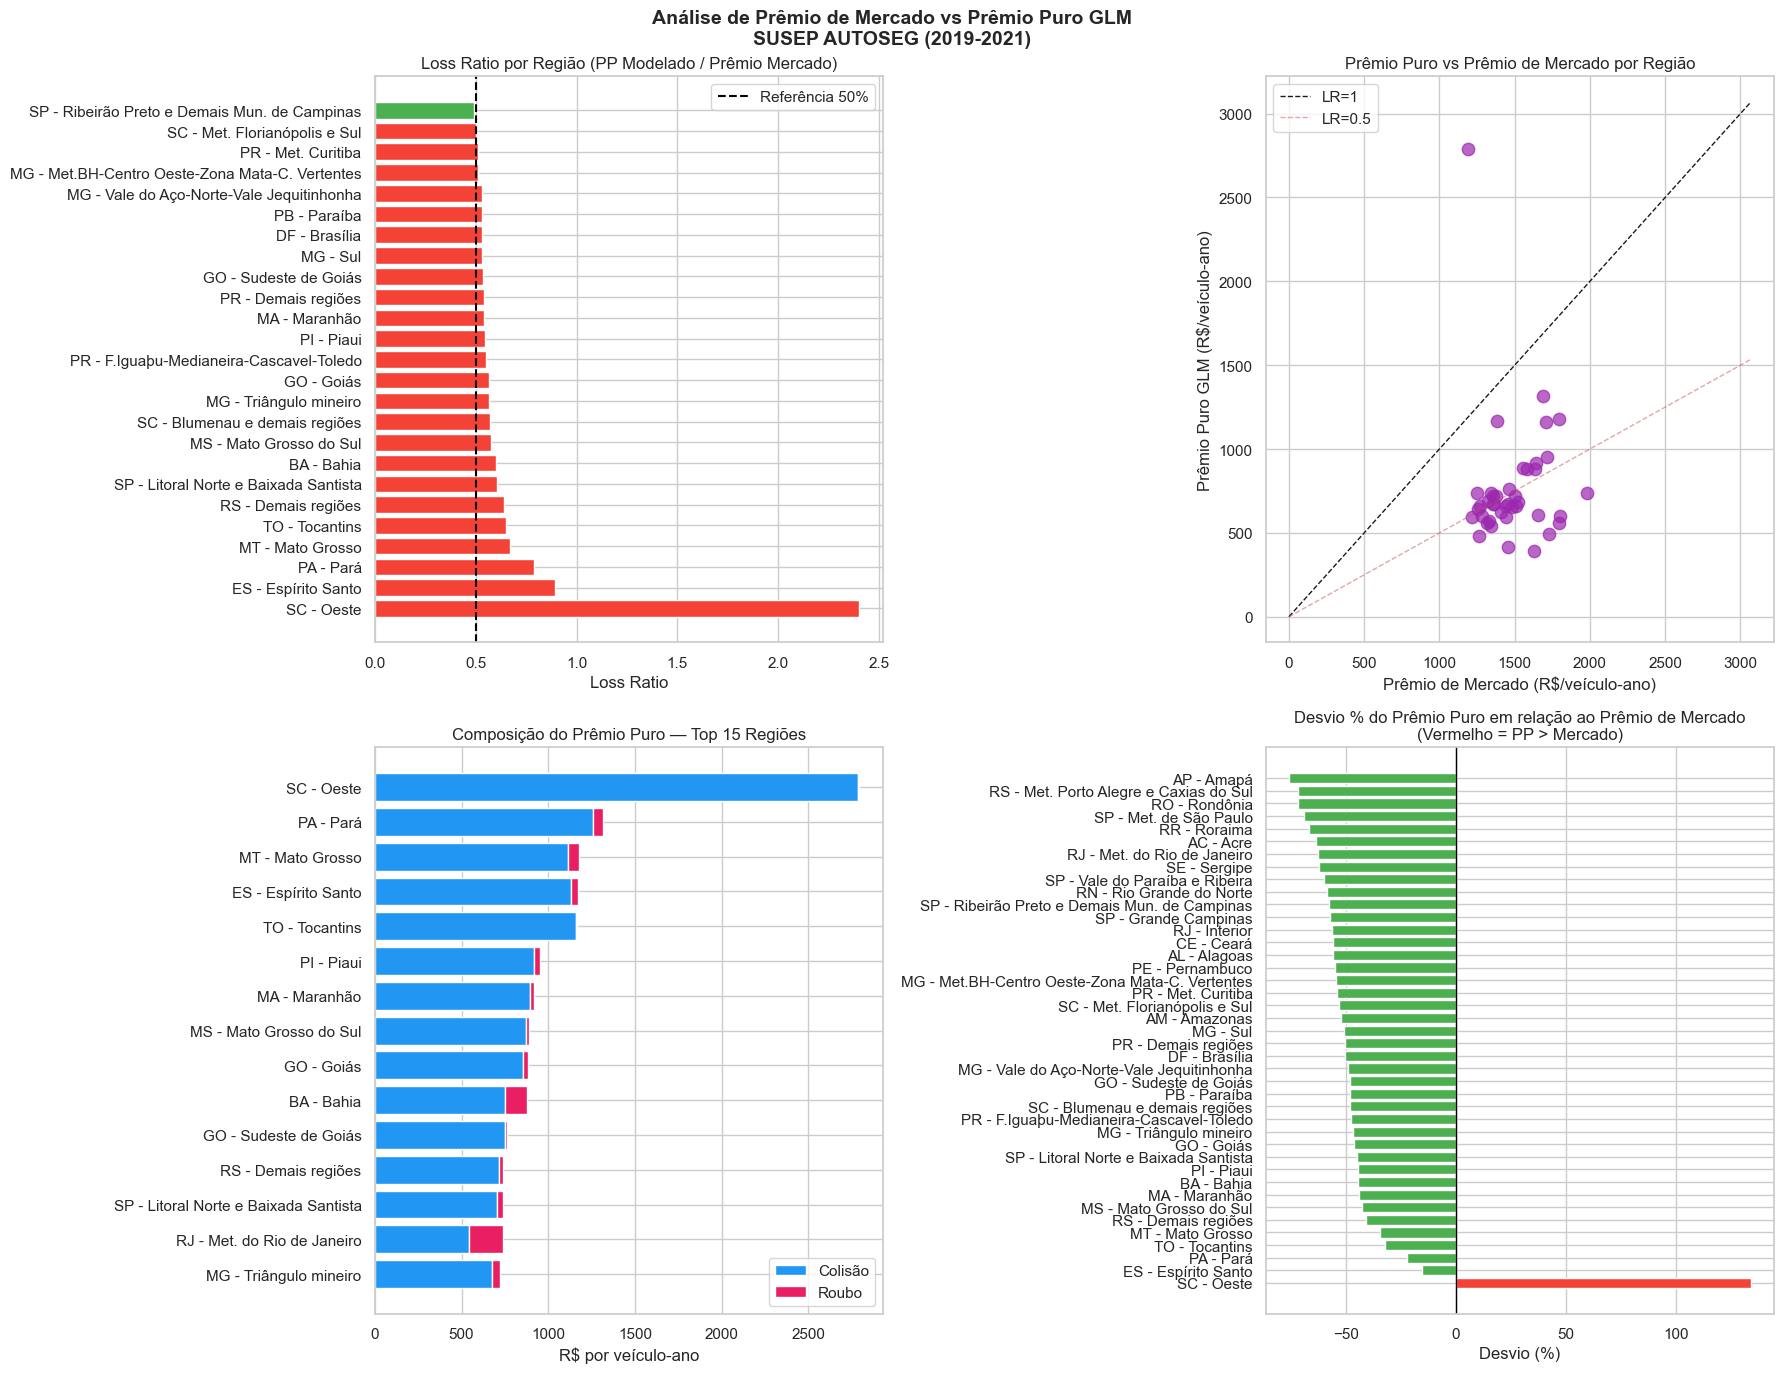

Figura salva: 05_market_analysis_regional.png


In [5]:
# ============================================================
# 5. VISUALIZAÇÃO — ANÁLISE REGIONAL
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Análise de Prêmio de Mercado vs Prêmio Puro GLM\nSUSEP AUTOSEG (2019-2021)',
             fontsize=14, fontweight='bold')

# 1. Loss ratio por região
ax1 = axes[0, 0]
reg_plot = reg_agg.sort_values('loss_ratio', ascending=False).head(25)
colors_lr = ['#F44336' if v > 0.5 else '#4CAF50' for v in reg_plot['loss_ratio']]
ax1.barh(reg_plot['regiao_desc'], reg_plot['loss_ratio'], color=colors_lr)
ax1.axvline(0.5, color='black', linestyle='--', linewidth=1.5,
            label='Referência 50%')
ax1.set_title('Loss Ratio por Região (PP Modelado / Prêmio Mercado)')
ax1.set_xlabel('Loss Ratio')
ax1.legend()

# 2. Scatter prêmio puro vs mercado
ax2 = axes[0, 1]
ax2.scatter(reg_agg['premio_rel'], reg_agg['pp_total'],
            alpha=0.7, color='#9C27B0', s=80)
max_val = max(reg_agg['premio_rel'].max(), reg_agg['pp_total'].max()) * 1.1
ax2.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='LR=1')
ax2.plot([0, max_val], [0, max_val*0.5], 'r--', linewidth=1,
         alpha=0.5, label='LR=0.5')
ax2.set_xlabel('Prêmio de Mercado (R$/veículo-ano)')
ax2.set_ylabel('Prêmio Puro GLM (R$/veículo-ano)')
ax2.set_title('Prêmio Puro vs Prêmio de Mercado por Região')
ax2.legend()

# 3. Composição prêmio puro por região (top 15)
ax3 = axes[1, 0]
top15 = reg_agg.nlargest(15, 'pp_total').sort_values('pp_total')
ax3.barh(top15['regiao_desc'], top15['pp_col'],
         color='#2196F3', label='Colisão')
ax3.barh(top15['regiao_desc'], top15['pp_rou'],
         left=top15['pp_col'], color='#E91E63', label='Roubo')
ax3.set_title('Composição do Prêmio Puro — Top 15 Regiões')
ax3.set_xlabel('R$ por veículo-ano')
ax3.legend()

# 4. Desvio percentual do prêmio puro vs mercado
ax4 = axes[1, 1]
reg_dev = reg_agg.sort_values('desvio_pct', ascending=False)
colors_dev = ['#F44336' if v > 0 else '#4CAF50' for v in reg_dev['desvio_pct']]
ax4.barh(reg_dev['regiao_desc'], reg_dev['desvio_pct'], color=colors_dev)
ax4.axvline(0, color='black', linestyle='-', linewidth=1)
ax4.set_title('Desvio % do Prêmio Puro em relação ao Prêmio de Mercado\n(Vermelho = PP > Mercado)')
ax4.set_xlabel('Desvio (%)')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/05_market_analysis_regional.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: 05_market_analysis_regional.png")

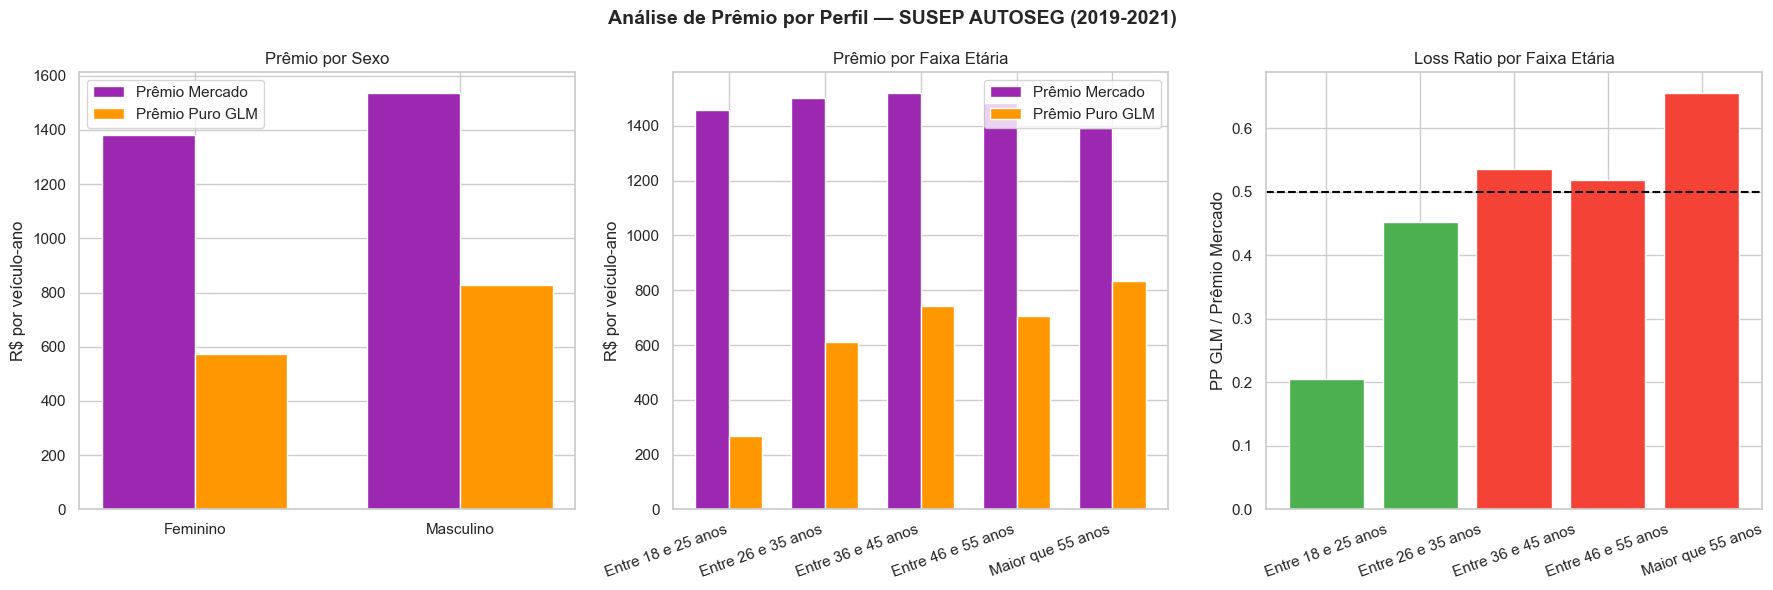

Figura salva: 05_market_analysis_perfil.png

Resumo por sexo:
           premio_rel  pp_total  loss_ratio
sexo_desc                                  
Feminino      1382.87    574.30        0.46
Masculino     1535.14    829.53        0.60

Resumo por faixa etária:
                    premio_rel  pp_total  loss_ratio
faixa_etaria_desc                                   
Entre 18 e 25 anos     1456.09    267.05        0.21
Entre 26 e 35 anos     1499.56    610.61        0.45
Entre 36 e 45 anos     1518.71    741.44        0.54
Entre 46 e 55 anos     1482.45    707.17        0.52
Maior que 55 anos      1392.43    831.81        0.66


In [6]:
# ============================================================
# 6. ANÁLISE POR PERFIL
# ============================================================

ordem_idades = ['Entre 18 e 25 anos','Entre 26 e 35 anos',
                'Entre 36 e 45 anos','Entre 46 e 55 anos','Maior que 55 anos']

perfil_sexo = df_lr.groupby('sexo_desc').agg(
    premio_rel=('premio_rel', 'mean'),
    pp_total=('pp_total_glm', 'mean'),
    loss_ratio=('loss_ratio_total', 'mean')
).loc[['Feminino','Masculino']]

perfil_idade = df_lr[df_lr['faixa_etaria'] > 0].groupby('faixa_etaria_desc').agg(
    premio_rel=('premio_rel', 'mean'),
    pp_total=('pp_total_glm', 'mean'),
    loss_ratio=('loss_ratio_total', 'mean')
).reindex(ordem_idades)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análise de Prêmio por Perfil — SUSEP AUTOSEG (2019-2021)',
             fontsize=14, fontweight='bold')

# 1. Por sexo
ax1 = axes[0]
x = np.arange(len(perfil_sexo))
w = 0.35
ax1.bar(x - w/2, perfil_sexo['premio_rel'], w,
        label='Prêmio Mercado', color='#9C27B0')
ax1.bar(x + w/2, perfil_sexo['pp_total'], w,
        label='Prêmio Puro GLM', color='#FF9800')
ax1.set_xticks(x)
ax1.set_xticklabels(perfil_sexo.index)
ax1.set_title('Prêmio por Sexo')
ax1.set_ylabel('R$ por veículo-ano')
ax1.legend()

# 2. Por faixa etária
ax2 = axes[1]
x2 = np.arange(len(perfil_idade))
ax2.bar(x2 - w/2, perfil_idade['premio_rel'], w,
        label='Prêmio Mercado', color='#9C27B0')
ax2.bar(x2 + w/2, perfil_idade['pp_total'], w,
        label='Prêmio Puro GLM', color='#FF9800')
ax2.set_xticks(x2)
ax2.set_xticklabels(perfil_idade.index, rotation=20, ha='right')
ax2.set_title('Prêmio por Faixa Etária')
ax2.set_ylabel('R$ por veículo-ano')
ax2.legend()

# 3. Loss ratio por faixa etária
ax3 = axes[2]
colors_lr = ['#F44336' if v > 0.5 else '#4CAF50'
             for v in perfil_idade['loss_ratio']]
ax3.bar(perfil_idade.index, perfil_idade['loss_ratio'],
        color=colors_lr, edgecolor='white')
ax3.axhline(0.5, color='black', linestyle='--', linewidth=1.5)
ax3.set_title('Loss Ratio por Faixa Etária')
ax3.set_ylabel('PP GLM / Prêmio Mercado')
ax3.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/05_market_analysis_perfil.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: 05_market_analysis_perfil.png")

print("\nResumo por sexo:")
print(perfil_sexo.round(2))
print("\nResumo por faixa etária:")
print(perfil_idade.round(2))

In [7]:
# ============================================================
# 7. INSIGHTS E SUMÁRIO
# ============================================================

print("=" * 65)
print("SUMÁRIO — ANÁLISE DE PRÊMIO DE MERCADO")
print("=" * 65)
print(f"\nPreço de mercado médio:         R$ {df_lr['premio_rel'].mean():,.2f}")
print(f"Prêmio puro GLM médio:          R$ {df_lr['pp_total_glm'].mean():,.2f}")
print(f"  Colisão:                       R$ {df_lr['pp_col_glm'].mean():,.2f} "
      f"({df_lr['pp_col_glm'].mean()/df_lr['pp_total_glm'].mean():.1%})")
print(f"  Roubo:                         R$ {df_lr['pp_rou_glm'].mean():,.2f} "
      f"({df_lr['pp_rou_glm'].mean()/df_lr['pp_total_glm'].mean():.1%})")
print(f"\nLoss ratio médio:               {df_lr['loss_ratio_total'].mean():.2%}")

print(f"\nRegião com maior LR (subcotada):")
top1 = reg_agg.nlargest(1, 'loss_ratio').iloc[0]
print(f"  {top1['regiao_desc']}: LR={top1['loss_ratio']:.2%}, "
      f"PP=R${top1['pp_total']:,.0f}, Mercado=R${top1['premio_rel']:,.0f}")

print(f"\nRegião com menor LR (supercotada):")
bot1 = reg_agg.nsmallest(1, 'loss_ratio').iloc[0]
print(f"  {bot1['regiao_desc']}: LR={bot1['loss_ratio']:.2%}, "
      f"PP=R${bot1['pp_total']:,.0f}, Mercado=R${bot1['premio_rel']:,.0f}")

print(f"\nLIMITAÇÕES:")
print(f"  - Prêmio puro cobre colisão + roubo apenas (89.1% do risco total)")
print(f"  - Incêndio (1.3%) e outras coberturas (10.9%) não modeladas")
print(f"  - Prêmio de mercado é comercial (inclui carregamento, despesas, lucro)")
print(f"  - Loss ratio aqui é indicativo de adequação relativa, não absoluta")

# Salvar tabela regional
reg_agg.to_csv(f'{FIGURES_PATH}/05_loss_ratio_regional.csv', index=False)
print(f"\n✓ Tabela regional salva: 05_loss_ratio_regional.csv")

SUMÁRIO — ANÁLISE DE PRÊMIO DE MERCADO

Preço de mercado médio:         R$ 1,468.21
Prêmio puro GLM médio:          R$ 717.35
  Colisão:                       R$ 645.88 (90.0%)
  Roubo:                         R$ 71.46 (10.0%)

Loss ratio médio:               53.78%

Região com maior LR (subcotada):
  SC - Oeste: LR=239.94%, PP=R$2,790, Mercado=R$1,191

Região com menor LR (supercotada):
  AP - Amapá: LR=26.83%, PP=R$394, Mercado=R$1,631

LIMITAÇÕES:
  - Prêmio puro cobre colisão + roubo apenas (89.1% do risco total)
  - Incêndio (1.3%) e outras coberturas (10.9%) não modeladas
  - Prêmio de mercado é comercial (inclui carregamento, despesas, lucro)
  - Loss ratio aqui é indicativo de adequação relativa, não absoluta

✓ Tabela regional salva: 05_loss_ratio_regional.csv
